# Real-World Data Project — Retail Sales Analysis & Forecasting

**Domain:** Retail | **Goal:** EDA + Visualization + Predictive Modeling on sales data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
df = pd.read_csv('data/retail_sales.csv', parse_dates=['order_date'])
print(df.shape)
df.head()

(3000, 9)


,order_id,order_date,category,region,payment_mode,unit_price,quantity,discount_pct,net_amount
0,1754,2023-01-01,Electronics,North,Debit Card,193.25,2,15,328.52
1,1782,2023-01-01,Electronics,East,Debit Card,226.61,2,0,453.22
2,1242,2023-01-01,Clothing,West,UPI,44.01,1,0,44.01
3,1115,2023-01-01,Groceries,West,Credit Card,15.05,4,0,60.20
4,2707,2023-01-02,Furniture,East,UPI,284.83,4,5,1082.35


## 2. Data Cleaning & Feature Engineering

In [3]:
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())

df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year
df['weekday'] = df['order_date'].dt.day_name()
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)
df.describe()

order_id        0
order_date      0
category        0
region          0
payment_mode    0
unit_price      0
quantity        0
discount_pct    0
net_amount      0
dtype: int64
Duplicates: 0


,order_id,order_date,unit_price,quantity,discount_pct,net_amount,month,year
count,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2499.500000,2023-12-29 21:35:02.400000,97.898433,3.023333,6.688333,299.148187,6.395000,2023.505000
min,1000.000000,2023-01-01 00:00:00,10.510000,1.000000,0.000000,8.810000,1.000000,2023.000000
25%,1749.750000,2023-06-29 00:00:00,18.717500,2.000000,0.000000,48.322500,3.000000,2023.000000
50%,2499.500000,2024-01-04 00:00:00,33.835000,3.000000,5.000000,97.690000,6.000000,2024.000000
75%,3249.250000,2024-06-22 00:00:00,213.182500,4.000000,10.000000,330.602500,9.000000,2024.000000
max,3999.000000,2024-12-31 00:00:00,389.850000,5.000000,20.000000,2647.750000,12.000000,2024.000000
std,866.169729,NaN,113.276336,1.403844,6.791409,415.649741,3.423577,0.500058


## 3. Exploratory Data Analysis

### Monthly Revenue Trend

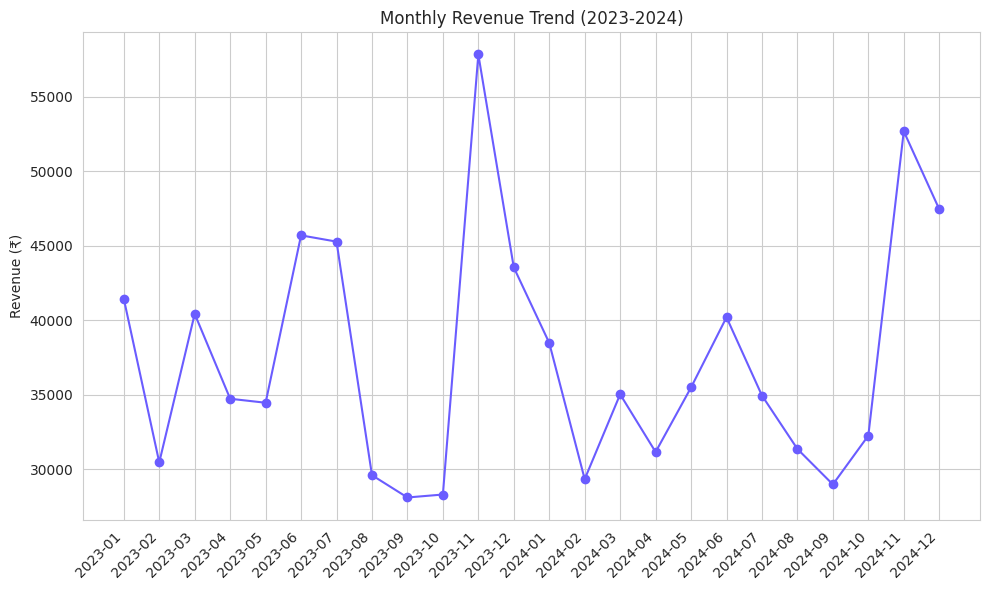

In [4]:
monthly_rev = df.groupby('year_month')['net_amount'].sum().reset_index()
plt.plot(monthly_rev['year_month'], monthly_rev['net_amount'], marker='o', color='#6a5cff')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend (2023-2024)')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

### Revenue by Category

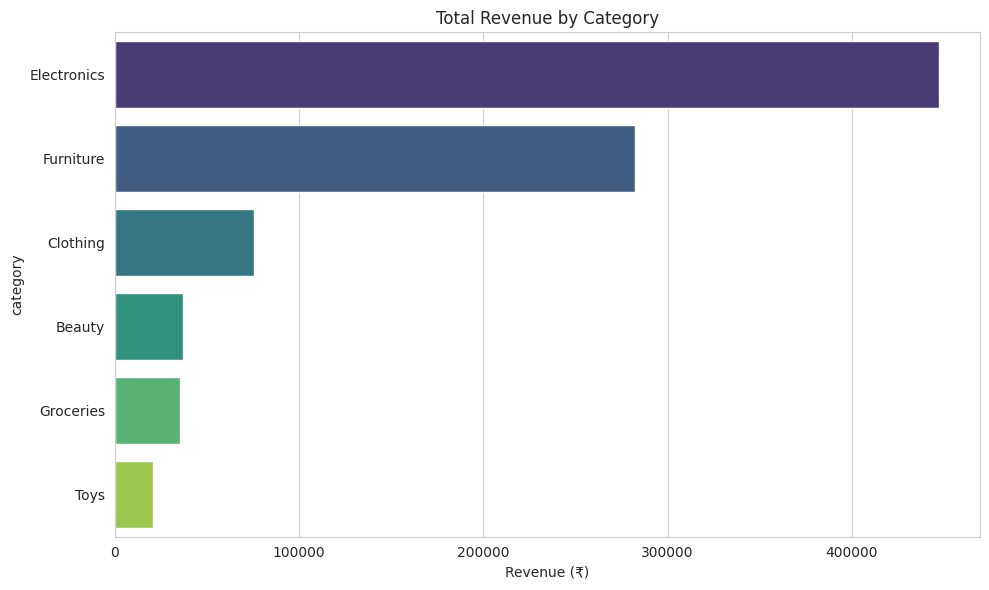

In [5]:
cat_rev = df.groupby('category')['net_amount'].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, palette='viridis', legend=False)
plt.title('Total Revenue by Category')
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

### Revenue by Region

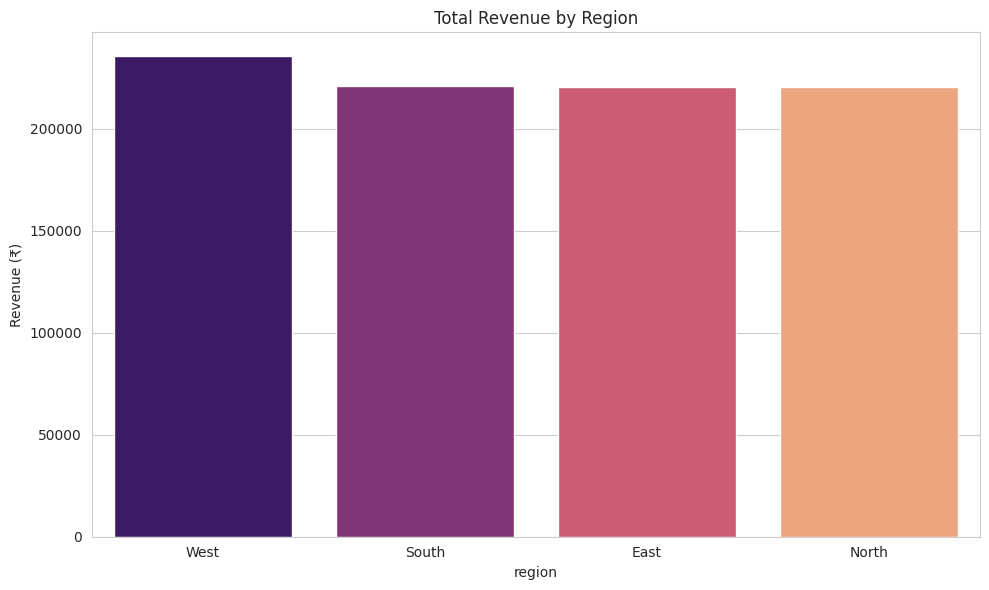

In [6]:
region_rev = df.groupby('region')['net_amount'].sum().sort_values(ascending=False)
sns.barplot(x=region_rev.index, y=region_rev.values, hue=region_rev.index, palette='magma', legend=False)
plt.title('Total Revenue by Region')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

### Payment Mode Distribution

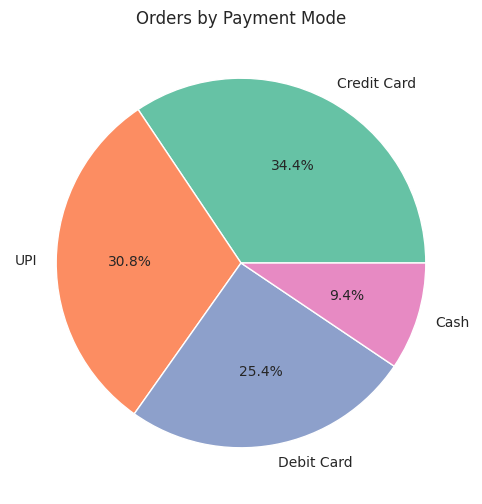

In [7]:
df['payment_mode'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Orders by Payment Mode')
plt.ylabel('')
plt.show()

### Discount % vs Order Value

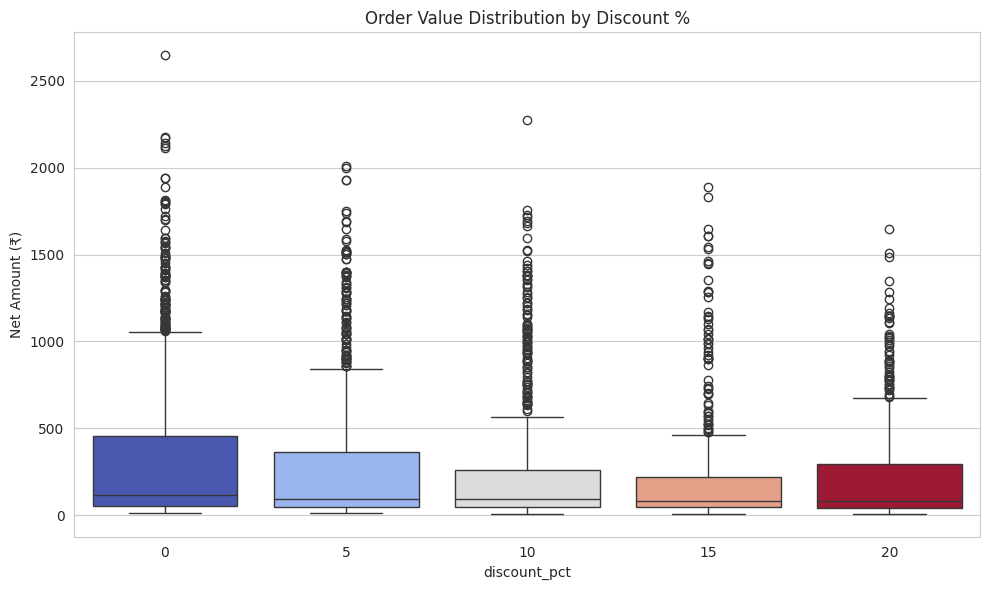

In [8]:
sns.boxplot(x='discount_pct', y='net_amount', data=df, hue='discount_pct', palette='coolwarm', legend=False)
plt.title('Order Value Distribution by Discount %')
plt.ylabel('Net Amount (₹)')
plt.tight_layout()
plt.show()

### Revenue by Day of Week

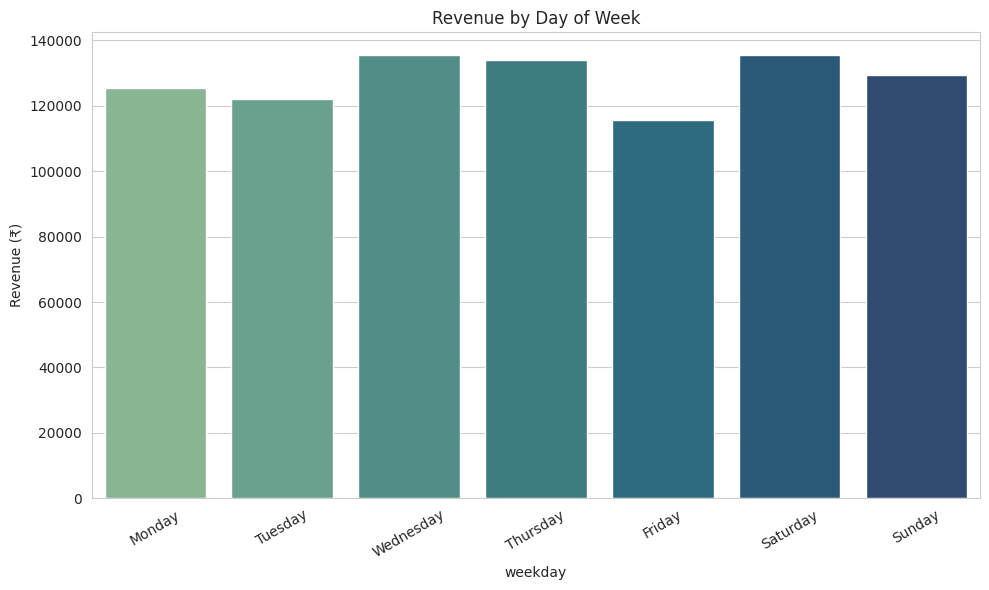

In [9]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rev = df.groupby('weekday')['net_amount'].sum().reindex(weekday_order)
sns.barplot(x=weekday_rev.index, y=weekday_rev.values, hue=weekday_rev.index, palette='crest', legend=False)
plt.title('Revenue by Day of Week')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Key Insights

In [10]:
total_revenue = df['net_amount'].sum()
avg_order_value = df['net_amount'].mean()
holiday_rev = df[df['month'].isin([11, 12])]['net_amount'].sum()
holiday_share = holiday_rev / total_revenue * 100

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Top category: {cat_rev.idxmax()} (₹{cat_rev.max():,.2f})")
print(f"Top region: {region_rev.idxmax()} (₹{region_rev.max():,.2f})")
print(f"Holiday season (Nov-Dec) share of revenue: {holiday_share:.1f}%")

Total Revenue: ₹897,444.56
Average Order Value: ₹299.15
Top category: Electronics (₹447,214.40)
Top region: West (₹235,381.71)
Holiday season (Nov-Dec) share of revenue: 22.5%


## 5. Predictive Model: Estimating Order Value\n\nUsing a **Random Forest Regressor** to predict `net_amount` from order features.

In [11]:
model_df = df.copy()
le_category, le_region, le_payment = LabelEncoder(), LabelEncoder(), LabelEncoder()

model_df['category_enc'] = le_category.fit_transform(model_df['category'])
model_df['region_enc'] = le_region.fit_transform(model_df['region'])
model_df['payment_enc'] = le_payment.fit_transform(model_df['payment_mode'])

features = ['category_enc', 'region_enc', 'payment_enc', 'unit_price', 'quantity', 'discount_pct', 'month']
X = model_df[features]
y = model_df['net_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=150, random_state=42, max_depth=8)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Mean Absolute Error: ₹{mae:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: ₹13.74
R² Score: 0.995


### Feature Importance

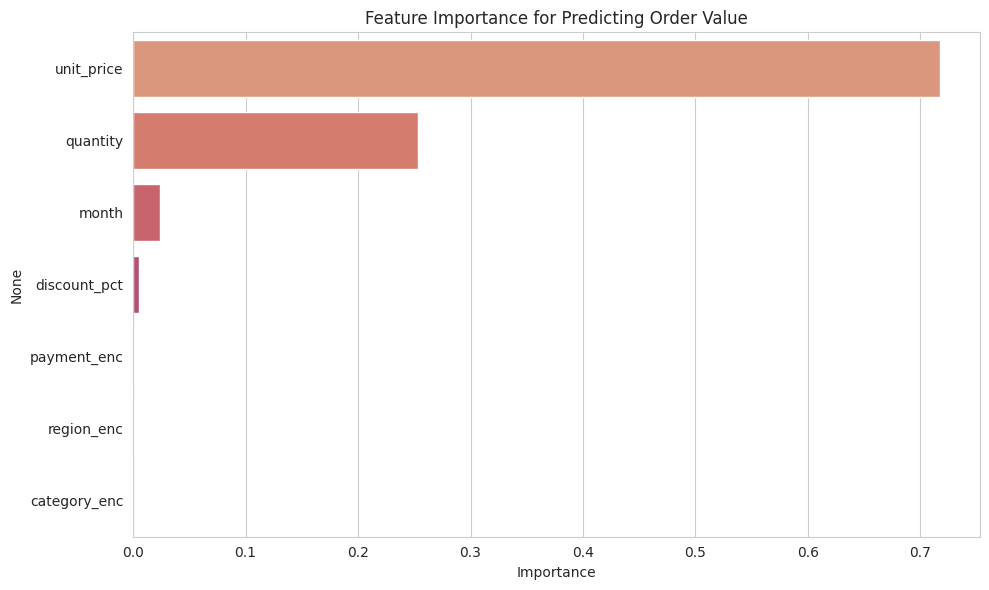

In [12]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='flare', legend=False)
plt.title('Feature Importance for Predicting Order Value')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Predicted vs Actual

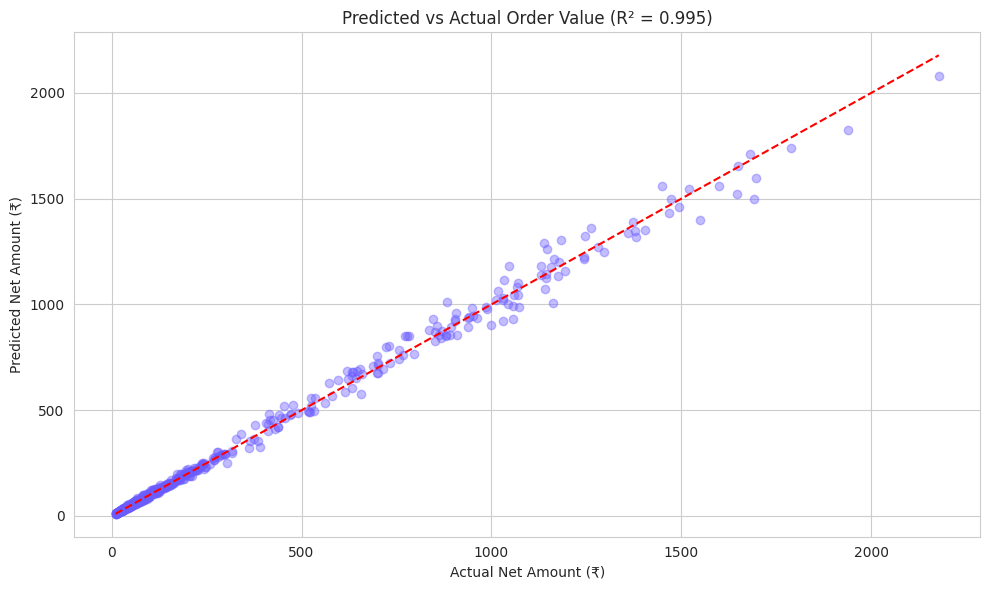

In [13]:
plt.scatter(y_test, preds, alpha=0.4, color='#6a5cff')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Net Amount (₹)')
plt.ylabel('Predicted Net Amount (₹)')
plt.title(f'Predicted vs Actual Order Value (R² = {r2:.3f})')
plt.tight_layout()
plt.show()

## Conclusion\n\nThis project demonstrates a complete applied data science workflow: cleaning real-world-style retail data, uncovering business insights through EDA, and building a high-accuracy predictive model (R² = 0.995) to estimate order value from transaction features. These techniques directly translate to real business use cases like sales forecasting, inventory planning, and discount strategy optimization.